# IceCube 2D GNN

In [654]:
import os
import numpy as np
from matplotlib import pyplot as plt
from functools import partial

import torch
import torch.nn as nn
import torch.optim as optim
from torchsummary import summary
from torch_geometric.nn import EdgeConv, DynamicEdgeConv, global_mean_pool
from torch_geometric.nn.pool import knn_graph

import helper_icecube as ic
import helper_dl as dl

In [655]:
# If the kernel is not restarted, packages are not reloaded by default
# This is to make sure the changes in the python scripts are loaded
import importlib

importlib.reload(ic)
importlib.reload(dl);

### File paths and flags

In [656]:
DATA_PATH = "../datasets/icecube"
PLOT_PATH = "/mnt/Datos/LaTeX/deep-learning/ex4/figures"
MODEL_PATH = "../models"

if not os.path.exists(DATA_PATH):
    raise Exception("Data folder does not exist")
if not os.path.exists(PLOT_PATH):
    raise Exception("Plots folder does not exist")
if not os.path.exists(MODEL_PATH):
    raise Exception("Model folder does not exist")

In [657]:
# Flags
TRAIN = False # Set to False to load a pre-trained model and skip training
SAVE_MODEL = True
SAVE_PLOTS = True

# Model name
SAVE_MODEL_NAME = "icecube_gnn.pth"
LOAD_MODEL_NAME = "icecube_gnn1.pth"

# Plot names
if not SAVE_PLOTS:
    PLOT_PATH = None

### Loading data

In [658]:
# Load the data
train_dataset, val_dataset, test_dataset = ic.load_icecube_data(DATA_PATH)

We inspect the data to understand how it is stored in the `awkward` arrays.

In [659]:
# to get familiar with the dataset, let's inspect it.
print(f"The training dataset contains {len(train_dataset)} events.")
print(f"The validation dataset contains {len(val_dataset)} events.")
print(f"The test dataset contains {len(test_dataset)} events.")

The training dataset contains 10001 events.
The validation dataset contains 10001 events.
The test dataset contains 10001 events.


In [660]:
print(f"The training dataset has the following columns: {train_dataset.fields}")
print(f"The validation dataset has the following columns: {val_dataset.fields}")
print(f"The test dataset has the following columns: {test_dataset.fields}")

The training dataset has the following columns: ['xpos', 'ypos', 'data', 'energy', 'xdir', 'ydir']
The validation dataset has the following columns: ['xpos', 'ypos', 'data', 'energy', 'xdir', 'ydir']
The test dataset has the following columns: ['xpos', 'ypos', 'data', 'energy', 'xdir', 'ydir']


In [661]:
# print the first event of the training dataset
print(f"The first event of the training dataset is: {train_dataset[0]}")

The first event of the training dataset is: {xpos: 3.94, ypos: -7.12, data: [[14.5, ...], ...], energy: 10, xdir: 1, ...}


In [662]:
# We are interested in the labels xpos and ypos. This is the position of the neutrino interaction that we want to predict.
print(f"The first event of the training dataset has the following labels: {train_dataset['xpos'][0]}, {train_dataset['ypos'][0]}")
# Awkward arrays also allow us to obtain the 'xpos' and 'ypos' label for all events in the dataset
print(f"The first 10 labels of the training dataset are: {train_dataset['xpos'][:10]}, {train_dataset['ypos'][:10]}")

The first event of the training dataset has the following labels: 3.9371957858673263, -7.117557573556748
The first 10 labels of the training dataset are: [3.94, -9.2, 6.35, 6.41, -7.42, -7.27, 9.1, -1.87, -2.57, 0.981], [-7.12, -1.42, -4.1, 3.23, 4.68, -0.412, -0.377, -4.93, 1.34, 4.59]


In [663]:
# The data can be accessed by using the 'data' key.
# The data is a 3D array with the first dimension being the number of events,
# the second dimension being the the three features (time, x, y)
# the third dimension being the number of hits,
print(f"The first event of the training dataset has {len(train_dataset['data'][0][0])} hits, i.e., detected photons.")

The first event of the training dataset has 12 hits, i.e., detected photons.


In [664]:
# Let's loop over all hits and print the time, x, and y coordinates of the first event.
for i in range(len(train_dataset['data'][0, 0])):
    print(f"Hit {i}: time = {train_dataset['data'][0,0,i]}, x = {train_dataset['data'][0,1, i]}, y = {train_dataset['data'][0,2,i]}")

Hit 0: time = 14.490445777588475, x = -2.5, y = -2.5
Hit 1: time = 17.1297022177257, x = -2.5, y = -2.5
Hit 2: time = 8.996675814194964, x = 2.5, y = -2.5
Hit 3: time = 12.021784213609394, x = 2.5, y = -2.5
Hit 4: time = 12.923289636173713, x = 2.5, y = -2.5
Hit 5: time = 25.1516276582378, x = -2.5, y = -0.8333333333333333
Hit 6: time = 15.286326473533162, x = 0.8333333333333335, y = -0.8333333333333333
Hit 7: time = 15.14788039212255, x = 2.5, y = -0.8333333333333333
Hit 8: time = 16.565114961505415, x = -0.8333333333333333, y = 0.8333333333333335
Hit 9: time = 19.47621700139486, x = -0.8333333333333333, y = 0.8333333333333335
Hit 10: time = 16.912010076540938, x = 2.5, y = 2.5
Hit 11: time = 19.57845737402364, x = 2.5, y = 2.5


In [665]:
# To get all hit times of the first event, you can use the following code:
print(f"The first event of the training dataset has the following hit times: {train_dataset['data'][0, 0]}")
print(f"The first event of the training dataset has the following hit x positions: {train_dataset['data'][0, 1]}")
print(f"The first event of the training dataset has the following hit y positions: {train_dataset['data'][0, 2]}")

The first event of the training dataset has the following hit times: [14.5, 17.1, 9, 12, 12.9, 25.2, 15.3, 15.1, 16.6, 19.5, 16.9, 19.6]
The first event of the training dataset has the following hit x positions: [-2.5, -2.5, 2.5, 2.5, 2.5, -2.5, 0.833, 2.5, -0.833, -0.833, 2.5, 2.5]
The first event of the training dataset has the following hit y positions: [-2.5, -2.5, -2.5, -2.5, -2.5, -0.833, ..., -0.833, 0.833, 0.833, 2.5, 2.5]


### Hyperparameter selection

In [666]:
# General hyperparameters
learning_rate = 1e-4
batch_size = 32
num_epochs = 100
patience = 10 # Training loop with early stopping, if the validation loss does not improve for 'patience' epochs

# GNN hyperparameters. We use a dictionary to save them together with the model
model_hyperparams = {
        'k': 5, # number of nearest neighbors for the graph construction
        'dims1': [32, 64],
        'dims2': [64, 128],
        'dims3': [128, 128],
        'dimMLP': 64
    }

### Prepare data por training

In [667]:
# Normalize the labels
train_dataset_norm, [means, stds] = ic.normalize_data(train_dataset)
val_dataset_norm, _ = ic.normalize_data(val_dataset)
test_dataset_norm, _ = ic.normalize_data(test_dataset)

# Create the dataloaders
train_loader, val_loader, test_loader = ic.create_dataloaders(train_dataset_norm, val_dataset_norm, test_dataset_norm, batch_size=batch_size)

In [668]:
# To get all hit times of the first event, you can use the following code:
print(f"The first event of the training dataset has the following hit times: {train_dataset['data'][0, 0]}")
print(f"The first event of the training dataset has the following hit x positions: {train_dataset['data'][0, 1]}")
print(f"The first event of the training dataset has the following hit y positions: {train_dataset['data'][0, 2]}")

The first event of the training dataset has the following hit times: [14.5, 17.1, 9, 12, 12.9, 25.2, 15.3, 15.1, 16.6, 19.5, 16.9, 19.6]
The first event of the training dataset has the following hit x positions: [-2.5, -2.5, 2.5, 2.5, 2.5, -2.5, 0.833, 2.5, -0.833, -0.833, 2.5, 2.5]
The first event of the training dataset has the following hit y positions: [-2.5, -2.5, -2.5, -2.5, -2.5, -0.833, ..., -0.833, 0.833, 0.833, 2.5, 2.5]


### Definition of the model and the loss function

In [669]:
class KernelMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, out_dim):
        super(KernelMLP, self).__init__()
    
        self.MLP = nn.Sequential(
            # First layer: Input -> Hidden
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            
            # Second layer: Hidden -> Output
            nn.Linear(hidden_dim, out_dim)
        )
        
    def forward(self, x):
        return self.MLP(x)

In [670]:
# Defintion of the GNN model
# Use the DynamicEdgeConv layer from the pytorch geometric package like this:
# MLP is a Multi-Layer Perceptron that is used to compute the edge features, you still need to define it.
# The input dimension to the MLP should be twice the number of features in the input data (i.e., 2 * n_features),
# because the edge features are computed from the concatenation of the two nodes that are connected by the edge.
# The output dimension of the MLP is the new feauture dimension of this graph layer.
class IceCube_GNN(nn.Module):
    def __init__(self, k, 
                 dims1, # dimensions of the first graph layer
                 dims2, # dimensions of the second graph layer
                 dims3, # dimensions of the third graph layer
                 dimMLP  # hidden dimension of the final MLP layer
            ):
        
        super(IceCube_GNN, self).__init__()
        
        n_features = 3 # time, x, y
        # Define a function that creates the edges of the graph
        self.create_edges = partial(knn_graph, k=k) # k is the number of nearest neighbors to consider

        # Define the graph layers
        self.layer_list = nn.ModuleList([
            EdgeConv(KernelMLP(2*n_features, dims1[0], dims1[1]), aggr='mean'),
            EdgeConv(KernelMLP(2*dims1[1], dims2[0], dims2[1]), aggr='mean'),
            EdgeConv(KernelMLP(2*dims2[1], dims3[0], dims3[1]), aggr='mean'),
            ])
        
        # Final MLP to predict x and y
        self.MLP = nn.Sequential(
            nn.Linear(dims3[1], dimMLP),
            nn.BatchNorm1d(dimMLP),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(dimMLP, 2)
        ) 

    def forward(self, data):
        # data is a batch graph item. it contains a list of tensors (x) and how the batch is structured along this list (batch)
        x = data.x
        batch = data.batch
        device = x.device

        # loop over the EdgeConv layers:
        for layer in self.layer_list:
            edge_index = self.create_edges(x.cpu(), batch=batch.cpu())
            edge_index = edge_index.to(device)
            x = layer(x, edge_index)
        
        # the output of the last layer has dimensions (n_batch, n_nodes, graph_feature_dimension)
        # where n_batch is the number of graphs in the batch and n_nodes is the number of nodes in the graph
        # i.e. one output per node (i.e. the hits in the event).
        # To combine all node feauters into single prediction, we recommend to use global pooling
        x = global_mean_pool(x, batch) # -> (n_batch, output_dim)
        # x is now a tensor of shape (n_batch, output_dim)

        # either your last graph feature dimension is already the output dimension you want to predict
        # or you need to add a final MLP layer to map the output dimension to the number of labels you want to predict
        x = self.MLP(x)

        return x

In [671]:
# Define the loss function in a compatible way with the training function
def MSE_loss(inputs, targets, model):
    output = model(inputs)
    return nn.MSELoss()(output, targets)

### Training the neural network

In [672]:
# Choose the best device
device = dl.get_device()
print(f"Using device: {device}")

Using device: xpu


In [673]:
if TRAIN:
    # Select the loss function
    loss_fn = MSE_loss

    # Initialize the model and the optimizer
    model = IceCube_GNN(**model_hyperparams).to(device)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    # Print the model summary
    summary(model);

In [674]:
if TRAIN:
    # Train the model
    train_losses, val_losses = dl.train_nn(train_loader, val_loader, model, loss_fn, optimizer,
                                        num_epochs=num_epochs, patience=patience, device=device)

In [675]:
# Plot training/validation loss
if TRAIN:
    dl.plot_losses(train_losses, val_losses, PATH=PLOT_PATH)

In [676]:
# Save model
if TRAIN and SAVE_MODEL:
    hyperparams = {
        'learning_rate': learning_rate,
        'batch_size': batch_size,
        'num_epochs': num_epochs,
        'patience': patience,
        'model_hyperparams': model_hyperparams
    }
    dl.save_model(model, hyperparams, PATH=f"{MODEL_PATH}/{SAVE_MODEL_NAME}")

### Evaluating the model

In [677]:
# Load model if it was not trained in this run
if not TRAIN:
    loss_fn = MSE_loss
    model, _ = dl.load_model(IceCube_GNN, PATH=f"{MODEL_PATH}/{LOAD_MODEL_NAME}")
    summary(model);

Layer (type:depth-idx)                   Param #
├─ModuleList: 1-1                        --
|    └─EdgeConv: 2-1                     --
|    |    └─MeanAggregation: 3-1         --
|    |    └─KernelMLP: 3-2               2,400
|    └─EdgeConv: 2-2                     --
|    |    └─MeanAggregation: 3-3         --
|    |    └─KernelMLP: 3-4               16,704
|    └─EdgeConv: 2-3                     --
|    |    └─MeanAggregation: 3-5         --
|    |    └─KernelMLP: 3-6               49,664
├─Sequential: 1-2                        --
|    └─Linear: 2-4                       8,256
|    └─BatchNorm1d: 2-5                  128
|    └─ReLU: 2-6                         --
|    └─Dropout: 2-7                      --
|    └─Linear: 2-8                       130
Total params: 77,282
Trainable params: 77,282
Non-trainable params: 0


In [678]:
# Compute the test predictions and loss
pos_test_pred_norm, test_loss = dl.test_nn(test_loader, model, loss_fn, device)
pos_test_pred_norm = pos_test_pred_norm.reshape(-1, 2)

if TRAIN:
    print(f"Final Train Loss: {train_losses[-1]:.4f}")
    print(f"Final Validation Loss: {val_losses[-1]:.4f}")
print(f"Final Test Loss: {test_loss:.4f}")

Final Test Loss: 0.1341


In [679]:
# Denormalize the predictions
pos_test_pred = dl.denormalize_labels(pos_test_pred_norm, n_labels=2, means=means, stds=stds)

# Extract the true labels
x_test = test_dataset['xpos'].to_numpy()
y_test = test_dataset['ypos'].to_numpy()
pos_test = np.stack((x_test, y_test), axis=1)

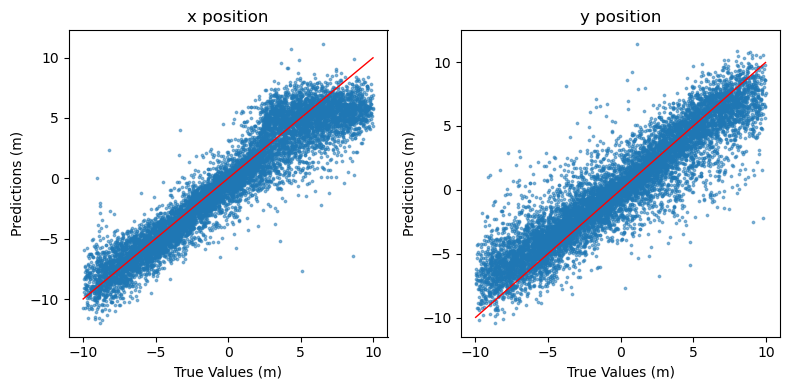

In [680]:
# Plot predicted values vs true values
dl.plot_predicted_vs_true(pos_test, pos_test_pred, n_labels=2, 
                          label_names=['x position', 'y position'], units = ['m', 'm'],
                          PATH=PLOT_PATH)

Bias in x position: -0.428 m
Std of x position: 1.63 m
Bias in y position: 0.271 m
Std of y position: 1.96 m


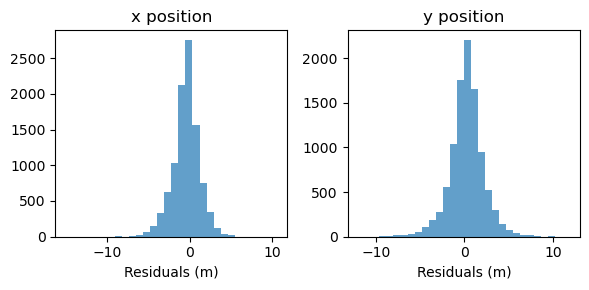

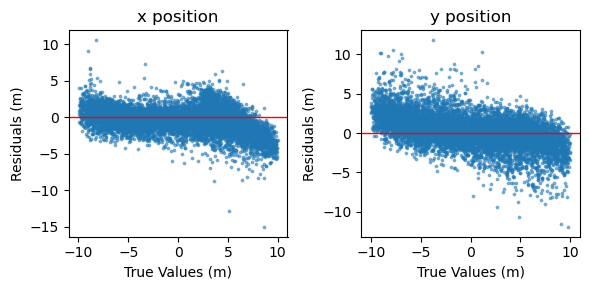

In [681]:
bias, std = dl.plot_residuals(pos_test, pos_test_pred, n_labels=2, 
                              label_names=['x position', 'y position'], units = ['m', 'm'],
                              PATH=PLOT_PATH)